In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 1. Load the competition datasets
## Read csv files

train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')
extern_data = pd.read_csv('/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv')


# 2. Print high-level overview
print(" DATASET DIMENSIONS ")
print(f"Train rows: {train_df.shape[0]:,}, Columns: {train_df.shape[1]}")
print(f"Test rows:  {test_df.shape[0]:,}, Columns: {test_df.shape[1]}")

# 3. Quick peek at the first 3 rows
print("TRAIN DATA PREVIEW ")
display(train_df.head(3))

=== DATASET DIMENSIONS ===
Train rows: 668,665, Columns: 15
Test rows:  286,571, Columns: 14
=== TRAIN DATA PREVIEW ===


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.00,23.40,2,3,7,1.00,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.00,5.00,1,2,2,4.00,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.00,36.80,1,8,15,5.00,Female,Urban,Sedan,No,Yes,Low,Yes


In [9]:
#  Check Missing Values 
print(" Missing val in TRAIN ")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Zero missing values")


#  Target Conversion Rate Summary
print("\nCONVERSION RATE")
overall_conv = train_df[target].mean() * 100
print(f"Overall Buying Rate: {overall_conv:.2f}%\n")
# 2. Target Distribution (EV Intent)
target_col = 'Will_Buy_EV'
print(f"\n '{target_col}' DISTRIBUTION")
target_counts = train_df[target_col].value_counts(dropna=False)
target_pct = train_df[target_col].value_counts(normalize=True, dropna=False) * 100

dist_df = pd.DataFrame({'Count': target_counts, 'Percentage': target_pct})
display(dist_df)

 Missing val in TRAIN 
Zero missing values

CONVERSION RATE
Overall Buying Rate: 17.46%


 'Will_Buy_EV' DISTRIBUTION


,Count,Percentage
Will_Buy_EV,,
0,551886,82.54
1,116779,17.46


=== SEGMENT CONVERSION RATES VS. BASELINE (17.5%) ===


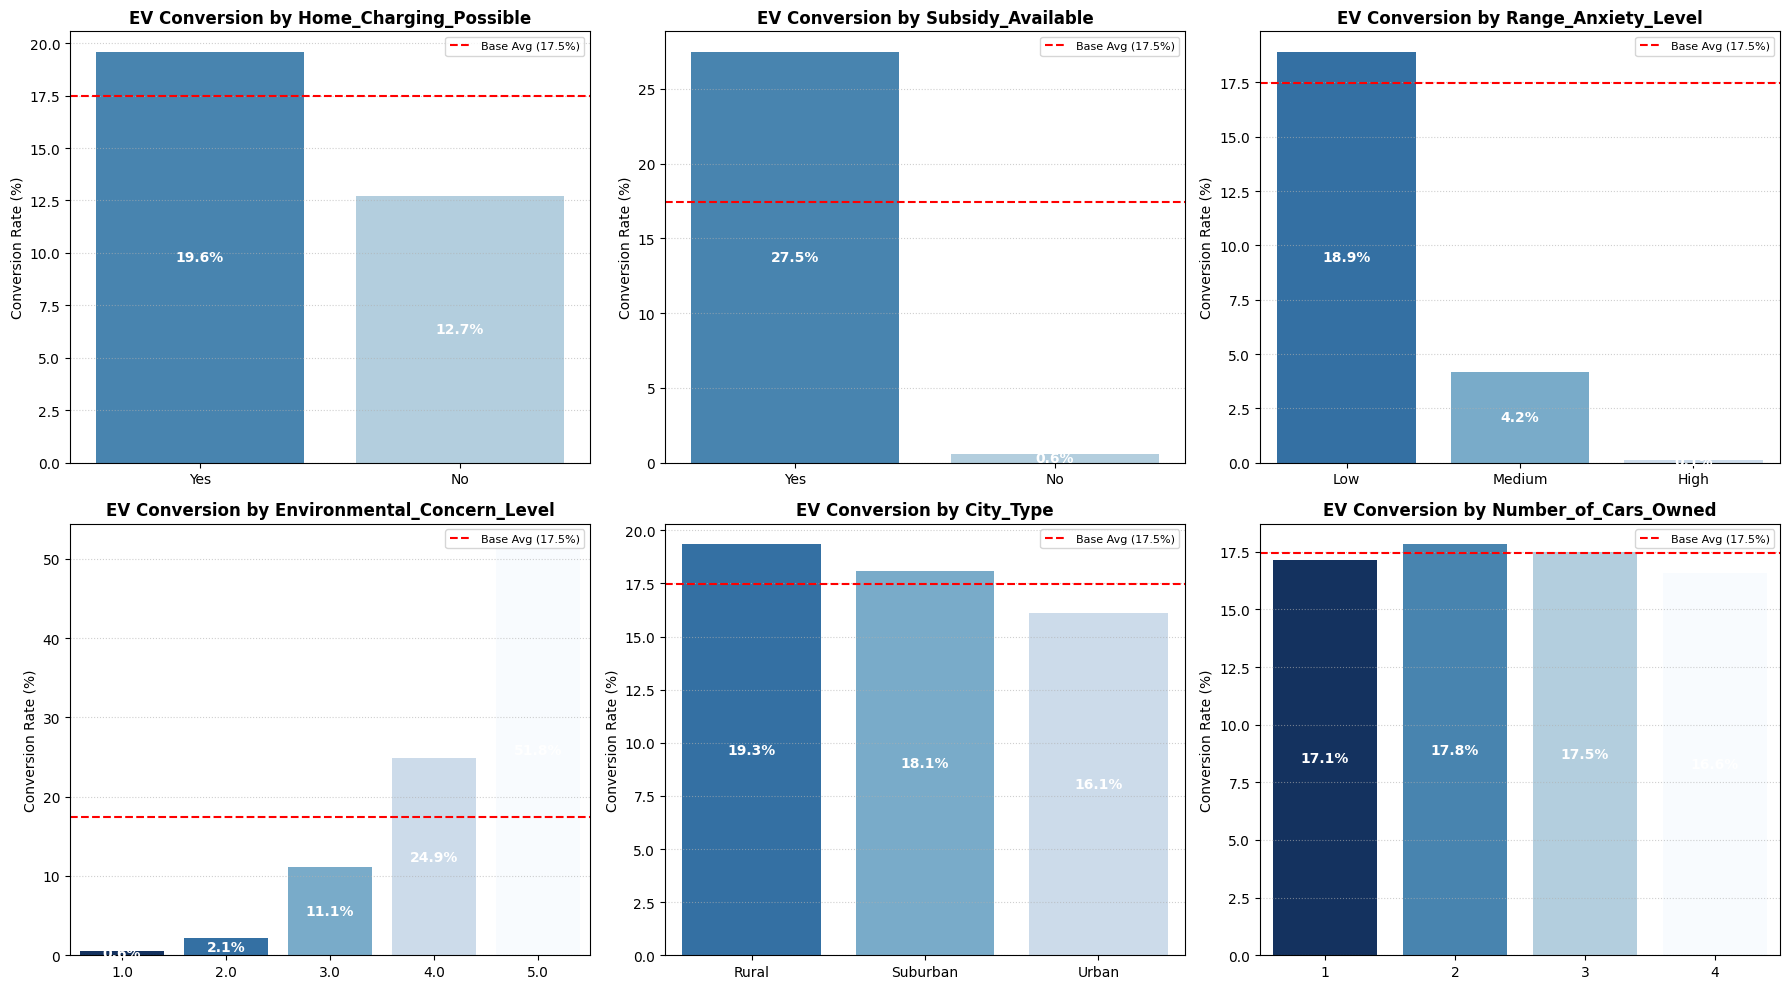

In [11]:
# primary categorical features 
cat_cols = [
    'Home_Charging_Possible', 
    'Subsidy_Available', 
    'Range_Anxiety_Level', 
    'Environmental_Concern_Level',
    'City_Type', 
    'Number_of_Cars_Owned'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

print(" SEGMENT CONVERSION RATES VS. BASELINE (17.5%) ")
for i, col in enumerate(cat_cols):
    #  volume count and intent conversion rate
    segment_stats = train_df.groupby(col)[target].agg(
        Total_Customers='count',
        Buyers='sum',
        Conversion_Rate=lambda x: x.mean() * 100
    ).reset_index()
    
    # Sort by conversion rate descending
    segment_stats = segment_stats.sort_values(by='Conversion_Rate', ascending=False)
    
    # Plot Conversion Rate
    sns.barplot(
        data=segment_stats, 
        x=col, 
        y='Conversion_Rate', 
        hue=col,
        legend=False,
        ax=axes[i], 
        palette='Blues_r'
    )
    axes[i].axhline(overall_conv, color='red', linestyle='--', linewidth=1.5, label=f'Base Avg ({overall_conv:.1f}%)')
    axes[i].set_title(f'EV Conversion by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Conversion Rate (%)')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    #  numerical labels
    for bar in axes[i].patches:
        height = bar.get_height()
        axes[i].annotate(f"{height:.1f}%",
                         (bar.get_x() + bar.get_width() / 2, height / 2),
                         ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

=== 1. EXTERNAL DATASET AUDIT ===
External Data Shape: 10,000 rows, 15 columns
Missing values in external data:
Annual_Income_USD              178
Daily_Commute_km               181
Environmental_Concern_Level    184
dtype: int64

External Dataset EV Conversion: 17.50% (vs Train: 17.46%)
External Dead Zone ($38k-$42k) : 223 people, Conversion: 10.31%
-> If External Dead Zone > 0%, the competition dead zone is 100% a synthetic generation artifact!


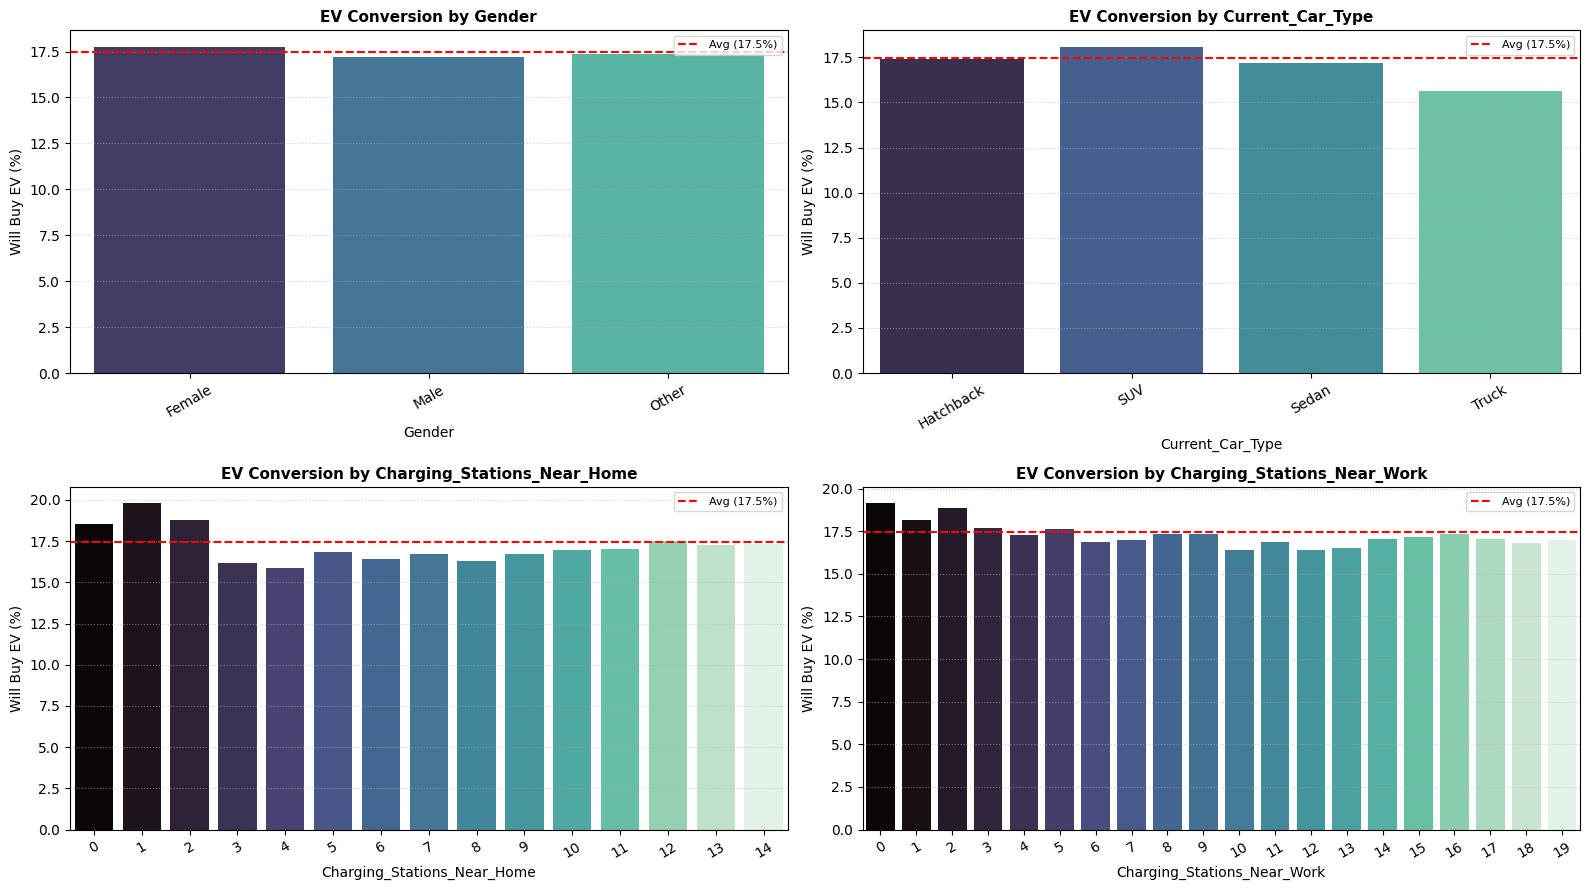

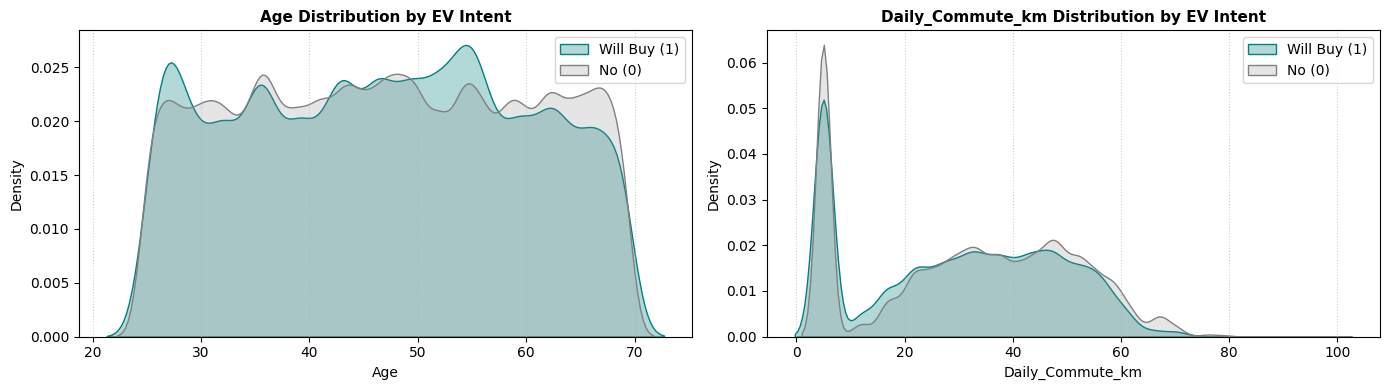

In [14]:
# ==========================================
# 1. EXTERNAL DATASET AUDIT & COMPARISON
# ==========================================
print("=== 1. EXTERNAL DATASET AUDIT ===")
print(f"External Data Shape: {extern_data.shape[0]:,} rows, {extern_data.shape[1]} columns")

# Check for missing values in external data
ext_nulls = extern_data.isnull().sum()
print("Missing values in external data:")
print(ext_nulls[ext_nulls > 0] if ext_nulls.sum() > 0 else "Zero missing values")

# Compare Target & Dead Zone in External Data vs Competition Train
ext_target_rate = extern_data['Will_Buy_EV'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).mean() * 100
ext_dead_zone = extern_data[(extern_data['Annual_Income_USD'] >= 38000) & (extern_data['Annual_Income_USD'] <= 42000)]
ext_dead_conv = ext_dead_zone['Will_Buy_EV'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).mean() * 100

print(f"\nExternal Dataset EV Conversion: {ext_target_rate:.2f}% (vs Train: {overall_conv:.2f}%)")
print(f"External Dead Zone ($38k-$42k) : {len(ext_dead_zone)} people, Conversion: {ext_dead_conv:.2f}%")
print("-> If External Dead Zone > 0%, the competition dead zone is 100% a synthetic generation artifact!")

# ==========================================
# 2. REMAINING CATEGORICAL METRICS
# ==========================================
remaining_cats = [
    'Gender',
    'Current_Car_Type',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(remaining_cats):
    # Calculate conversion rates
    stats = train_df.groupby(col, observed=False)['Will_Buy_EV'].agg(
        Total='count',
        Conversion_Rate=lambda x: x.mean() * 100
    ).reset_index()
    
    sns.barplot(
        data=stats, 
        x=col, 
        y='Conversion_Rate', 
        hue=col, 
        legend=False, 
        ax=axes[i], 
        palette='mako'
    )
    axes[i].axhline(overall_conv, color='red', linestyle='--', label=f'Avg ({overall_conv:.1f}%)')
    axes[i].set_title(f'EV Conversion by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Will Buy EV (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 3. CONTINUOUS METRICS: AGE & DAILY COMMUTE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cont_cols = ['Age', 'Daily_Commute_km']

for i, col in enumerate(cont_cols):
    sns.kdeplot(data=train_df[train_df['Will_Buy_EV'] == 1], x=col, label='Will Buy (1)', ax=axes[i], color='teal', fill=True, alpha=0.3)
    sns.kdeplot(data=train_df[train_df['Will_Buy_EV'] == 0], x=col, label='No (0)', ax=axes[i], color='gray', fill=True, alpha=0.2)
    axes[i].set_title(f'{col} Distribution by EV Intent', fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [17]:
# Cleaning the external benchmark dataset
print("=== CLEANING EXTERNAL DATASET ===")
print("Missing before cleaning:")
print(extern_data[['Annual_Income_USD', 'Daily_Commute_km', 'Environmental_Concern_Level']].isnull().sum())

# Impute continuous columns with median (robust against outliers)
extern_data['Annual_Income_USD'] = extern_data['Annual_Income_USD'].fillna(train_df['Annual_Income_USD'].median())
extern_data['Daily_Commute_km'] = extern_data['Daily_Commute_km'].fillna(train_df['Daily_Commute_km'].median())

# Impute discrete rating with mode (most frequent value)
extern_data['Environmental_Concern_Level'] = extern_data['Environmental_Concern_Level'].fillna(train_df['Environmental_Concern_Level'].mode()[0])

print("\nMissing after cleaning in external data:")
print(extern_data[['Annual_Income_USD', 'Daily_Commute_km', 'Environmental_Concern_Level']].isnull().sum())

=== CLEANING EXTERNAL DATASET ===
Missing before cleaning:
Annual_Income_USD              0
Daily_Commute_km               0
Environmental_Concern_Level    0
dtype: int64

Missing after cleaning in external data:
Annual_Income_USD              0
Daily_Commute_km               0
Environmental_Concern_Level    0
dtype: int64


=== INCOME SLICES WITH UNUSUALLY LOW/ZERO CONVERSION ===


,Income_Bin,Respondents,EV_Buyers,Conversion_Rate
0,"(30000, 35000]",2,1,50.00
1,"(35000, 40000]",571,0,0.00
2,"(40000, 45000]",3666,160,4.36
3,"(45000, 50000]",8932,367,4.11
4,"(50000, 55000]",18919,1823,9.64
5,"(55000, 60000]",23506,2463,10.48
6,"(60000, 65000]",37690,1896,5.03
7,"(65000, 70000]",33892,4715,13.91
8,"(70000, 75000]",45588,5702,12.51
9,"(75000, 80000]",40840,6115,14.97


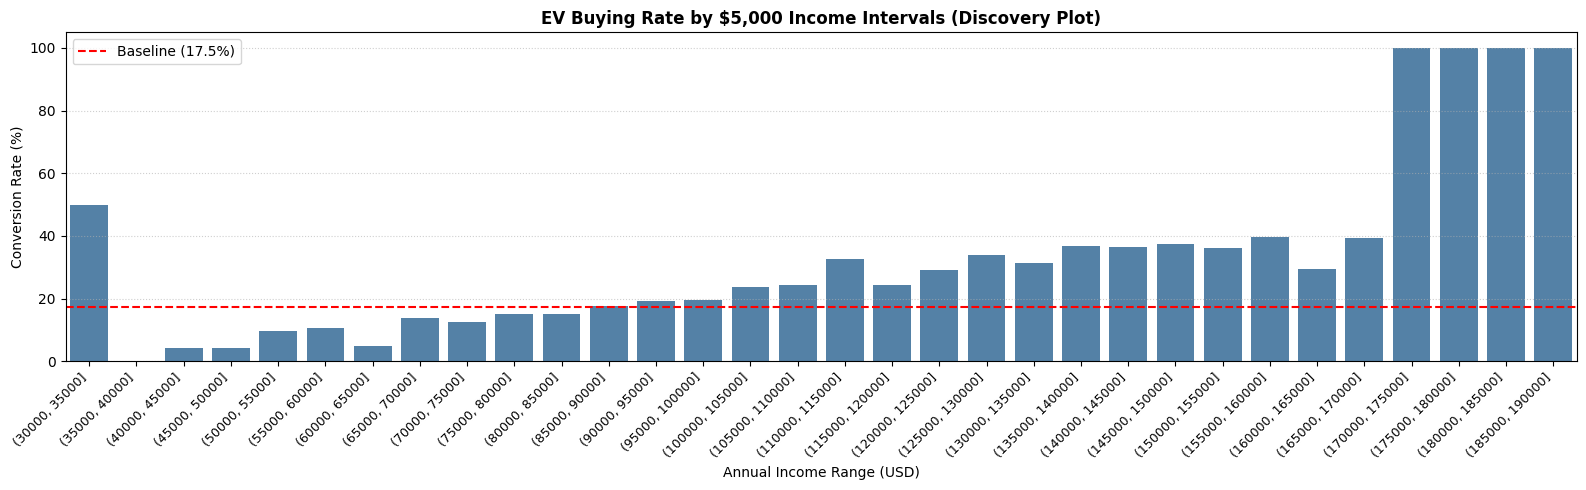

In [13]:
# 1. Slice Annual Income into $5,000 intervals from min to max
income_bins = np.arange(30000, 195000, 5000)
train_df['Income_Bin'] = pd.cut(train_df['Annual_Income_USD'], bins=income_bins)

# 2. Compute conversion rate and sample count for each income slice
income_stats = train_df.groupby('Income_Bin', observed=False)[target].agg(
    Respondents='count',
    EV_Buyers='sum',
    Conversion_Rate=lambda x: x.mean() * 100
).reset_index()

# 3. Look at the data table where conversion drops to ~0%

display(income_stats.head(10))

# 4. Plot the conversion curve across all income bins
plt.figure(figsize=(16, 5))
sns.barplot(data=income_stats, x='Income_Bin', y='Conversion_Rate', color='steelblue')
plt.axhline(overall_conv, color='red', linestyle='--', label=f'Baseline ({overall_conv:.1f}%)')
plt.title('EV Buying Rate by $5,000 Income Intervals ', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Annual Income Range (USD)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
# Filter survey respondents in the $38,000 to $42,000 income band
dead_zone = train_df[(train_df['Annual_Income_USD'] >= 38000) & (train_df['Annual_Income_USD'] <= 42000)]

total_in_zone = len(dead_zone)
buyers_in_zone = dead_zone[target].sum()
conv_in_zone = dead_zone[target].mean() * 100

print("=== INCOME DEAD ZONE VERIFICATION ($38k - $42k) ===")
print(f"Total respondents in this band : {total_in_zone:,}")
print(f"EV Buyers in this band         : {buyers_in_zone}")
print(f"Conversion Rate in this band   : {conv_in_zone:.3f}%")

=== INCOME DEAD ZONE VERIFICATION ($38k - $42k) ===
Total respondents in this band : 1,277
EV Buyers in this band         : 2
Conversion Rate in this band   : 0.157%


In [15]:
# 1. Define your hypothesized "Ideal Adopter" segment
ideal_filter = (
    (train_df['Subsidy_Available'] == 'Yes') &
    (train_df['Home_Charging_Possible'] == 'Yes') &
    (train_df['Range_Anxiety_Level'] == 'Low') &
    (train_df['Environmental_Concern_Level'] == 5)
)

# 2. Define the opposite "High-Friction" segment
friction_filter = (
    (train_df['Subsidy_Available'] == 'No') |
    (train_df['Range_Anxiety_Level'] == 'High') |
    (train_df['Environmental_Concern_Level'] <= 2)
)

ideal_segment = train_df[ideal_filter]
friction_segment = train_df[friction_filter]

print("=== TESTING YOUR HYPOTHESIS ===")
print(f"Dataset Baseline Rate: {overall_conv:.2f}%\n")

print(f"Ideal Adopter Segment (Your 4 Drivers Combined):")
print(f" - Size: {len(ideal_segment):,} respondents ({len(ideal_segment)/len(train_df):.2%})")
print(f" - EV Conversion Rate: {ideal_segment[target].mean() * 100:.2f}%")

print(f"\nHigh-Friction Segment (Lacks Subsidy / High Anxiety / Low Eco Concern):")
print(f" - Size: {len(friction_segment):,} respondents ({len(friction_segment)/len(train_df):.2%})")
print(f" - EV Conversion Rate: {friction_segment[target].mean() * 100:.2f}%")

=== TESTING YOUR HYPOTHESIS ===
Dataset Baseline Rate: 17.46%

Ideal Adopter Segment (Your 4 Drivers Combined):
 - Size: 69,398 respondents (10.38%)
 - EV Conversion Rate: 72.51%

High-Friction Segment (Lacks Subsidy / High Anxiety / Low Eco Concern):
 - Size: 419,500 respondents (62.74%)
 - EV Conversion Rate: 1.22%


In [24]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING
# ==========================================

def engineer_features(df):
    data = df.copy()
    
    # 1. Synthetic Artifact Flag: Income Dead Zone ($38k - $42k)
    data['is_dead_zone'] = (
        (data['Annual_Income_USD'] >= 38000.0) & 
        (data['Annual_Income_USD'] <= 42000.0)
    ).astype(int)
    
    # Ensure charging station values are numeric
    home_chg = pd.to_numeric(data['Charging_Stations_Near_Home'], errors='coerce').fillna(0)
    work_chg = pd.to_numeric(data['Charging_Stations_Near_Work'], errors='coerce').fillna(0)
    
    # 2. Total Public Charging Access
    data['Total_Charging_Access'] = home_chg + work_chg
    
    # 3. Commute-to-Income Economic Burden Ratio
    data['Commute_Income_Ratio'] = (data['Daily_Commute_km'] / (data['Annual_Income_USD'] + 1)) * 1000
    
    # 4. Short Commute Sweet Spot Flag (Identified in EDA spike at 5-12 km)
    data['Short_Commute_Sweetspot'] = (
        (data['Daily_Commute_km'] >= 4.0) & 
        (data['Daily_Commute_km'] <= 12.0)
    ).astype(int)
    
    # 5. High-Income Subsidized Buyer (Affluence + Incentive)
    median_income = 84880.0
    data['Subsidized_High_Income'] = (
        (data['Subsidy_Available'] == 'Yes') & 
        (data['Annual_Income_USD'] >= median_income)
    ).astype(int)
    
    # 6. High Anxiety Long Commute (Major friction point)
    data['High_Anxiety_Long_Commute'] = (
        (data['Range_Anxiety_Level'] == 'High') & 
        (data['Daily_Commute_km'] > 45.0)
    ).astype(int)
    
    # 7. Ideal Adopter Profile (Verified: 72.5% Conversion!)
    data['Ideal_Adopter_Profile'] = (
        (data['Subsidy_Available'] == 'Yes') &
        (data['Home_Charging_Possible'] == 'Yes') &
        (data['Range_Anxiety_Level'] == 'Low') &
        (pd.to_numeric(data['Environmental_Concern_Level'], errors='coerce') == 5)
    ).astype(int)

    return data

# Apply to all datasets
train_fe = engineer_features(train_df)
test_fe  = engineer_features(test_df)
extern_fe = engineer_features(extern_data)



# Verify lift of new engineered features
check_cols = ['is_dead_zone', 'Short_Commute_Sweetspot', 'Subsidized_High_Income', 'Ideal_Adopter_Profile']
for col in check_cols:
    conversion = train_fe.groupby(col)['Will_Buy_EV'].mean() * 100
    print(f"\nFeature: {col}")
    print(f"  Flag = 0: {conversion.get(0, 0):.2f}%")
    print(f"  Flag = 1: {conversion.get(1, 0):.2f}%")


Feature: is_dead_zone
  Flag = 0: 17.50%
  Flag = 1: 0.16%

Feature: Short_Commute_Sweetspot
  Flag = 0: 17.11%
  Flag = 1: 18.70%

Feature: Subsidized_High_Income
  Flag = 0: 7.97%
  Flag = 1: 37.14%

Feature: Ideal_Adopter_Profile
  Flag = 0: 11.09%
  Flag = 1: 72.51%


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import catboost as cb
import xgboost as xgb

# 1. Drop any temporary columns if they accidentally lingered
drop_lingering = ['Income_Bin', 'Fine_Income_Bin']
train_fe.drop(columns=[c for c in drop_lingering if c in train_fe.columns], inplace=True, errors='ignore')
test_fe.drop(columns=[c for c in drop_lingering if c in test_fe.columns], inplace=True, errors='ignore')

# 2. Re-identify categorical and numerical columns safely from train_fe
cat_features = train_fe.select_dtypes(include=['object', 'category']).columns.tolist()
if target in cat_features:
    cat_features.remove(target)

num_features = train_fe.select_dtypes(include=['number']).columns.tolist()
for col in ['id', target]:
    if col in num_features:
        num_features.remove(col)

print(f"Identified {len(num_features)} numerical features.")
print(f"Identified {len(cat_features)} categorical features: {cat_features}")

# 3. Cast categorical columns to 'category' dtype safely on both train and test
for col in cat_features:
    train_fe[col] = train_fe[col].astype('category')
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].astype('category')

print("\nData types prepared successfully for LightGBM!")

Identified 10 numerical features.
Identified 10 categorical features: ['Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

Data types prepared successfully for LightGBM!


In [21]:
# ==========================================
# PHASE 3: LIGHTGBM BASELINE TRAINING LOOP
# ==========================================

# Setup 5-Fold Stratified Cross-Validation
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

features = num_features + cat_features
X = train_fe[features]
y = train_fe[target]
X_test = test_fe[features]

# Storage for predictions and scores
oof_preds = np.zeros(len(train_fe))
test_preds = np.zeros(len(test_fe))
cv_scores = []

print(f"Training LightGBM across {FOLDS} folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # LightGBM Classifier Configuration
    model = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    # Train model with early stopping
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    # Predict probabilities on validation fold
    val_preds = model.predict_proba(X_va)[:, 1]
    oof_preds[val_idx] = val_preds
    
    # Evaluate fold AUC
    fold_auc = roc_auc_score(y_va, val_preds)
    cv_scores.append(fold_auc)
    print(f"Fold {fold+1} ROC-AUC: {fold_auc:.5f}")
    
    # Accumulate test predictions
    test_preds += model.predict_proba(X_test)[:, 1] / FOLDS

overall_oof_auc = roc_auc_score(y, oof_preds)
print(f"\n========================================")
print(f"Overall Out-of-Fold (OOF) ROC-AUC: {overall_oof_auc:.5f}")
print(f"========================================")

Training LightGBM across 5 folds...
Fold 1 ROC-AUC: 0.94018
Fold 2 ROC-AUC: 0.94122
Fold 3 ROC-AUC: 0.94275
Fold 4 ROC-AUC: 0.94202
Fold 5 ROC-AUC: 0.94131

Overall Out-of-Fold (OOF) ROC-AUC: 0.94149


In [27]:
# ==========================================
# COMPARISON: CATBOOST TRAINING LOOP
# ==========================================
from catboost import CatBoostClassifier

# Ensure all categorical columns are strings for CatBoost
X_cb = X.copy()
X_test_cb = X_test.copy()
for col in cat_features:
    X_cb[col] = X_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

cat_oof_preds = np.zeros(len(train_fe))
cat_test_preds = np.zeros(len(test_fe))
cat_scores = []

print("Training CatBoost across 5 folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y)):
    X_tr, y_tr = X_cb.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_cb.iloc[val_idx], y.iloc[val_idx]
    
    model_cat = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        eval_metric='AUC',
        cat_features=cat_features,
        random_seed=42,
        verbose=0
    )
    
    model_cat.fit(
        X_tr, y_tr,
        eval_set=(X_# ==========================================
# CLEAN CATBOOST TRAINING LOOP
# ==========================================
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Prepare clean data copies for CatBoost
X_cb = train_fe[num_features + cat_features].copy()
X_test_cb = test_fe[num_features + cat_features].copy()

# 2. CatBoost requires ALL categorical columns to be strings
for col in cat_features:
    X_cb[col] = X_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

y_cb = train_fe[target]

# 3. 5-Fold CV Training
cat_oof_preds = np.zeros(len(train_fe))
cat_test_preds = np.zeros(len(test_fe))
cat_scores = []

print("Training CatBoost across 5 folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y_cb)):
    X_tr, y_tr = X_cb.iloc[train_idx], y_cb.iloc[train_idx]
    X_va, y_va = X_cb.iloc[val_idx], y_cb.iloc[val_idx]
    
    model_cat = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        eval_metric='AUC',
        cat_features=cat_features,
        random_seed=42,
        verbose=0
    )
    
    model_cat.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=50
    )
    
    val_preds = model_cat.predict_proba(X_va)[:, 1]
    cat_oof_preds[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_va, val_preds)
    cat_scores.append(fold_auc)
    print(f"CatBoost Fold {fold+1} ROC-AUC: {fold_auc:.5f}")
    
    cat_test_preds += model_cat.predict_proba(X_test_cb)[:, 1] / FOLDS

cat_overall_auc = roc_auc_score(y_cb, cat_oof_preds)
print(f"\n========================================")
print(f"LightGBM OOF ROC-AUC        : 0.94149")
print(f"CatBoost Overall OOF ROC-AUC: {cat_overall_auc:.5f}")
print(f"========================================")va, y_va),
        early_stopping_rounds=50
    )
    
    val_preds = model_cat.predict_proba(X_va)[:, 1]
    cat_oof_preds[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_va, val_preds)
    cat_scores.append(fold_auc)
    print(f"CatBoost Fold {fold+1} ROC-AUC: {fold_auc:.5f}")
    
    cat_test_preds += model_cat.predict_proba(X_test_cb)[:, 1] / FOLDS

cat_overall_auc = roc_auc_score(y, cat_oof_preds)
print(f"\n========================================")
print(f"LightGBM OOF ROC-AUC : 0.94149")
print(f"CatBoost Overall OOF ROC-AUC: {cat_overall_auc:.5f}")
print(f"========================================")

Training CatBoost across 5 folds...


KeyboardInterrupt: 

In [23]:
# Check model overfitting by comparing Train AUC vs Validation AUC on Fold 1
model_check = lgb.LGBMClassifier(
    objective='binary', metric='auc', n_estimators=100, learning_rate=0.05, random_state=42
)

# Split fold 1 manually
for train_idx, val_idx in skf.split(X, y):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    model_check.fit(X_tr, y_tr)
    break

train_auc = roc_auc_score(y_tr, model_check.predict_proba(X_tr)[:, 1])
val_auc   = roc_auc_score(y_va, model_check.predict_proba(X_va)[:, 1])

print("=== OVERFITTING DIAGNOSTIC CHECK ===")
print(f"Training Set ROC-AUC   : {train_auc:.5f}")
print(f"Validation Set ROC-AUC : {val_auc:.5f}")
print(f"Difference             : {abs(train_auc - val_auc):.5f}")

=== OVERFITTING DIAGNOSTIC CHECK ===
Training Set ROC-AUC   : 0.94140
Validation Set ROC-AUC : 0.93900
Difference             : 0.00240


In [22]:
# ==========================================
# PHASE 4: GENERATE SUBMISSION FILE
# ==========================================

# 1. Ensure test_fe has all the exact same features used during training
X_test_final = test_fe[features]

# 2. test_preds was already accumulated and averaged across all 5 folds in our training loop!
# Let's verify its shape and distribution
print("=== TEST PREDICTIONS SUMMARY ===")
print(f"Test predictions shape: {test_preds.shape}")
print(f"Mean predicted probability: {test_preds.mean():.4f}")
print(f"Min predicted probability:  {test_preds.min():.4f}")
print(f"Max predicted probability:  {test_preds.max():.4f}\n")

# 3. Create the submission dataframe matching the sample_submission.csv format
submission = pd.DataFrame({
    'id': test_fe['id'],
    target: test_preds
})

# 4. Save to CSV
sub_file_name = 'submission_lgbm_baseline.csv'
submission.to_csv(sub_file_name, index=False)

print(f"Submission file '{sub_file_name}' successfully created and saved!")
display(submission.head(10))

=== TEST PREDICTIONS SUMMARY ===
Test predictions shape: (286571,)
Mean predicted probability: 0.1746
Min predicted probability:  0.0000
Max predicted probability:  0.9624

Submission file 'submission_lgbm_baseline.csv' successfully created and saved!


,id,Will_Buy_EV
0,668665,0.01
1,668666,0.02
2,668667,0.01
3,668668,0.00
4,668669,0.02
5,668670,0.01
6,668671,0.37
7,668672,0.00
8,668673,0.66
9,668674,0.01
